
# V2 — RUGD → RELLIS-3D Cross-dataset Vegetation Evaluation

This notebook follows the same experimental logic, model definitions, metric aggregation, prediction saving, and qualitative presentation as **01_rugd_indomain**.

### Experiment
- **Training domain:** RUGD
- **Test domain:** RELLIS-3D
- **Target-domain training/fine-tuning:** None
- **Models:** U-Net, DeepLabV3+, SegFormer-B0, ROD
- **Task:** binary ground / non-ground segmentation

### Vegetation-specific metrics
- Grass Ground Recall
- Tree Non-ground Recall
- Bush Non-ground Recall
- Bush Ground Leakage
- Vegetation Balanced Score (VBS)
- Vegetation Boundary F1

The original RELLIS-3D colour semantic annotations are used **only for vegetation ROI identification**.  
The processed binary RELLIS-3D masks remain the binary ground-truth labels used by the project.

### Qualitative output
The notebook also automatically selects:
- **5 successful vegetation scenes**
- **5 representative bush-failure scenes**

Each selected scene is shown with the same four-model comparison used in the RUGD experiment.


In [1]:

# 1. Install dependencies and clone the official ROD repository

!pip -q install segmentation-models-pytorch albumentations einops opencv-python-headless pandas matplotlib tqdm

import os
import sys

ROD_REPO = "/content/offroad_roadseg"

if not os.path.exists(ROD_REPO):
    !git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git {ROD_REPO}

if ROD_REPO not in sys.path:
    sys.path.insert(0, ROD_REPO)

print("ROD repository:", ROD_REPO)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.7 MB/s eta 0:00:00
Cloning into '/content/offroad_roadseg'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 17), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.32 MiB | 19.93 MiB/s, done.
Resolving deltas: 100% (17/17), done.
ROD repository: /content/offroad_roadseg


In [2]:

# 2. Imports, random seed and device

from pathlib import Path
from typing import Dict, Tuple
from collections import defaultdict
from io import BytesIO

import json
import re
import time
import shutil
import urllib.request
import zipfile
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:

# 3. Mount Drive and configure paths

from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# DATA
# ============================================================

RAW_RELLIS_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/raw/RELLIS-3D.zip"
)

PROCESSED_RELLIS_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/processed/"
    "RELLIS_3D_binary_processed.zip"
)

# ============================================================
# RUGD-trained checkpoints
# Same checkpoints as 01_rugd_indomain
# ============================================================

CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),

    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),

    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),

    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}

# ============================================================
# OUTPUT
# ============================================================

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/IRP/05_vegetation_evaluation/"
    "02_rellis_cross_dataset"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

# ============================================================
# LOCAL WORK DIR
# ============================================================

WORK_ROOT = Path(
    "/content/rellis_cross_vegetation_eval"
)

PROCESSED_EXTRACT_DIR = (
    WORK_ROOT / "processed"
)

INNER_ZIP_DIR = (
    WORK_ROOT / "raw_nested"
)

# ============================================================
# EXPERIMENT SETTINGS
# ============================================================

IMAGE_SIZE = (512, 512)

BATCH_SIZE = 4
NUM_WORKERS = 2

IGNORE_INDEX = 255
NON_GROUND_ID = 0
GROUND_ID = 1

BOUNDARY_TOLERANCE = 3

SAVE_PREDICTIONS = True

# Debug:
# use e.g. 50 for pipeline checking;
# restore to None for the formal experiment.
MAX_TEST_IMAGES = None

print("Output:", OUTPUT_ROOT)


Mounted at /content/drive
Output: /content/drive/MyDrive/IRP/05_vegetation_evaluation/02_rellis_cross_dataset


In [4]:

# 4. Check all required input files

for path in [
    RAW_RELLIS_ZIP,
    PROCESSED_RELLIS_ZIP,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required data file not found: {path}"
        )

print("DATA CHECK")
print("=" * 100)

print(
    "Raw RELLIS-3D:",
    RAW_RELLIS_ZIP
)

print(
    "Processed RELLIS-3D:",
    PROCESSED_RELLIS_ZIP
)


print("\nCHECKPOINT CHECK")
print("=" * 100)

for model_name, checkpoint_path in CHECKPOINTS.items():

    print(
        f"{model_name:14s} | "
        f"exists={checkpoint_path.exists()} | "
        f"{checkpoint_path}"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"{model_name} checkpoint not found: "
            f"{checkpoint_path}"
        )

print("\nAll required input files found.")


DATA CHECK
Raw RELLIS-3D: /content/drive/MyDrive/IRP/01_data/raw/RELLIS-3D.zip
Processed RELLIS-3D: /content/drive/MyDrive/IRP/01_data/processed/RELLIS_3D_binary_processed.zip

CHECKPOINT CHECK
U-Net          | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
DeepLabV3+     | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
SegFormer-B0   | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth
ROD            | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth

All required input files found.


In [5]:

# 5. Extract processed RELLIS-3D
#
# Unlike RUGD_processed.zip, the verified RELLIS processed archive
# contains a manifest.csv and binary_label_mapping.csv.
# We use the manifest to preserve EXACTLY the existing project test split.

def find_file_recursively(
    root: Path,
    filename: str,
):
    matches = list(
        Path(root).rglob(filename)
    )

    return (
        matches[0]
        if matches
        else None
    )


WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

PROCESSED_EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


manifest_existing = find_file_recursively(
    PROCESSED_EXTRACT_DIR,
    "manifest.csv",
)


if manifest_existing is None:

    print(
        "Extracting processed RELLIS-3D..."
    )

    with zipfile.ZipFile(
        PROCESSED_RELLIS_ZIP,
        "r",
    ) as archive:

        archive.extractall(
            PROCESSED_EXTRACT_DIR
        )


MANIFEST_PATH = find_file_recursively(
    PROCESSED_EXTRACT_DIR,
    "manifest.csv",
)

if MANIFEST_PATH is None:

    raise FileNotFoundError(
        "manifest.csv was not found after extracting "
        "RELLIS_3D_binary_processed.zip"
    )


DATA_ROOT = MANIFEST_PATH.parent

MAPPING_PATH = (
    DATA_ROOT
    / "binary_label_mapping.csv"
)


if not MAPPING_PATH.exists():

    raise FileNotFoundError(
        f"binary_label_mapping.csv not found: "
        f"{MAPPING_PATH}"
    )


print("DATA_ROOT :", DATA_ROOT)
print("MANIFEST  :", MANIFEST_PATH)
print("MAPPING   :", MAPPING_PATH)


Extracting processed RELLIS-3D...
DATA_ROOT : /content/rellis_cross_vegetation_eval/processed/RELLIS_3D_binary_processed
MANIFEST  : /content/rellis_cross_vegetation_eval/processed/RELLIS_3D_binary_processed/manifest.csv
MAPPING   : /content/rellis_cross_vegetation_eval/processed/RELLIS_3D_binary_processed/binary_label_mapping.csv


In [6]:

# 6. Read manifest and build the fixed RELLIS-3D test dataframe

manifest_df = pd.read_csv(
    MANIFEST_PATH
)

mapping_df = pd.read_csv(
    MAPPING_PATH
)


def resolve_column(
    dataframe,
    candidates,
    required=True,
):

    for column in candidates:

        if column in dataframe.columns:
            return column

    if required:

        raise KeyError(
            "Cannot resolve required column. "
            f"Candidates={candidates}; "
            f"available={dataframe.columns.tolist()}"
        )

    return None


split_col = resolve_column(
    manifest_df,
    [
        "split",
        "subset",
        "partition",
    ],
)

image_col = resolve_column(
    manifest_df,
    [
        "processed_image",
        "image_path",
        "image",
        "image_file",
    ],
)

mask_col = resolve_column(
    manifest_df,
    [
        "processed_mask",
        "mask_path",
        "mask",
        "label_path",
        "binary_mask",
    ],
)

sequence_col = resolve_column(
    manifest_df,
    [
        "sequence",
        "sequence_id",
        "seq",
    ],
)

source_mask_col = resolve_column(
    manifest_df,
    [
        "source_mask",
        "original_mask",
        "source_label",
        "semantic_mask",
    ],
)


def resolve_processed_path(
    value,
):

    path = Path(
        str(value)
    )

    if path.is_absolute():

        if path.exists():
            return str(path)

        # The original absolute Colab path may have changed.
        # Fall back to the basename / relative suffix below.

    relative_candidate = (
        DATA_ROOT
        / path
    )

    if relative_candidate.exists():
        return str(
            relative_candidate
        )

    # Try to find by path suffix inside the extracted processed archive.
    path_text = (
        str(path)
        .replace("\\", "/")
    )

    parts = [
        part
        for part in path_text.split("/")
        if part
    ]

    for depth in range(
        min(6, len(parts)),
        0,
        -1,
    ):

        suffix = Path(
            *parts[-depth:]
        )

        candidate = (
            DATA_ROOT
            / suffix
        )

        if candidate.exists():
            return str(
                candidate
            )

    # Final fallback: unique basename inside DATA_ROOT
    matches = list(
        DATA_ROOT.rglob(
            path.name
        )
    )

    if len(matches) == 1:
        return str(
            matches[0]
        )

    return str(
        relative_candidate
    )


def normalise_sequence(
    value,
):

    text = str(
        value
    ).strip()

    if re.fullmatch(
        r"\d+(\.0)?",
        text,
    ):

        return (
            f"{int(float(text)):05d}"
        )

    return text


work_df = (
    manifest_df.copy()
)


work_df["split_norm"] = (
    work_df[split_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "validation": "val",
        "valid": "val",
        "testing": "test",
    })
)


work_df["sequence_norm"] = (
    work_df[sequence_col]
    .map(normalise_sequence)
)


work_df["image_path_resolved"] = (
    work_df[image_col]
    .map(resolve_processed_path)
)


work_df["mask_path_resolved"] = (
    work_df[mask_col]
    .map(resolve_processed_path)
)


work_df["stem"] = (
    work_df[
        "image_path_resolved"
    ]
    .map(
        lambda path:
        Path(path).stem
    )
)


test_df = (
    work_df[
        work_df["split_norm"]
        == "test"
    ]
    .reset_index(drop=True)
)


if MAX_TEST_IMAGES is not None:

    test_df = (
        test_df
        .head(MAX_TEST_IMAGES)
        .copy()
    )


if len(test_df) == 0:

    raise RuntimeError(
        "No RELLIS-3D test samples were found in manifest.csv"
    )


missing_files = test_df[
    ~test_df[
        "image_path_resolved"
    ].map(os.path.exists)
    |
    ~test_df[
        "mask_path_resolved"
    ].map(os.path.exists)
]


if len(missing_files):

    display(
        missing_files[
            [
                image_col,
                mask_col,
                "image_path_resolved",
                "mask_path_resolved",
            ]
        ].head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_files)} test rows contain missing "
        "processed images/masks."
    )


print(
    "RELLIS-3D test images:",
    len(test_df)
)


display(
    test_df[
        [
            "split_norm",
            "sequence_norm",
            "stem",
            "image_path_resolved",
            "mask_path_resolved",
            source_mask_col,
        ]
    ].head()
)


RELLIS-3D test images: 899


,split_norm,sequence_norm,stem,image_path_resolved,mask_path_resolved,source_mask
0,test,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...
1,test,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...
2,test,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...
3,test,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...
4,test,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...


In [7]:

# 7. Extract and open the nested ORIGINAL colour-label ZIP
#
# Raw RELLIS-3D.zip contains:
# Rellis_3D_pylon_camera_node_label_color.zip
#
# We read semantic labels directly from the nested zip rather than
# extracting thousands of colour masks to Drive.

INNER_ZIP_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

INNER_LABEL_ZIP_PATH = (
    INNER_ZIP_DIR
    / "Rellis_3D_pylon_camera_node_label_color.zip"
)


if not INNER_LABEL_ZIP_PATH.exists():

    print(
        "Extracting nested RELLIS colour-label ZIP..."
    )

    with zipfile.ZipFile(
        RAW_RELLIS_ZIP,
        "r",
    ) as outer_archive:

        candidates = [
            member
            for member
            in outer_archive.namelist()
            if Path(member).name
            == "Rellis_3D_pylon_camera_node_label_color.zip"
        ]

        if not candidates:

            raise FileNotFoundError(
                "Rellis_3D_pylon_camera_node_label_color.zip "
                "was not found inside RELLIS-3D.zip"
            )

        selected_member = (
            candidates[0]
        )

        print(
            "Nested member:",
            selected_member
        )

        with outer_archive.open(
            selected_member,
            "r",
        ) as source:

            with open(
                INNER_LABEL_ZIP_PATH,
                "wb",
            ) as target:

                shutil.copyfileobj(
                    source,
                    target,
                )


raw_label_zip = zipfile.ZipFile(
    INNER_LABEL_ZIP_PATH,
    "r",
)

raw_members = (
    raw_label_zip.namelist()
)


print(
    "Colour-label ZIP members:",
    len(raw_members)
)


Extracting nested RELLIS colour-label ZIP...
Nested member: RELLIS-3D/Rellis_3D_pylon_camera_node_label_color.zip
Colour-label ZIP members: 6239


In [8]:

# 8. Build robust original-label ZIP path indices

def normalise_zip_path(
    path_value,
):

    return (
        str(path_value)
        .replace("\\", "/")
        .strip()
        .lstrip("./")
        .lstrip("/")
    )


normalised_to_member = {
    normalise_zip_path(
        member
    ): member
    for member
    in raw_members
}


suffix_lookup = defaultdict(
    list
)

filename_lookup = defaultdict(
    list
)


for member in raw_members:

    normalised = (
        normalise_zip_path(
            member
        )
    )

    if normalised.endswith("/"):
        continue

    parts = (
        normalised.split("/")
    )

    filename_lookup[
        parts[-1]
    ].append(
        member
    )


    for depth in range(
        2,
        min(
            8,
            len(parts),
        ) + 1,
    ):

        suffix = "/".join(
            parts[-depth:]
        )

        suffix_lookup[
            suffix
        ].append(
            member
        )


def resolve_raw_member(
    path_value,
):

    target = (
        normalise_zip_path(
            path_value
        )
    )

    if target in normalised_to_member:

        return (
            normalised_to_member[
                target
            ]
        )


    possible_targets = [
        target
    ]


    for prefix in [
        "Rellis-3D/",
        "RELLIS-3D/",
    ]:

        if target.startswith(
            prefix
        ):

            possible_targets.append(
                target[
                    len(prefix):
                ]
            )


    for candidate in possible_targets:

        if candidate in normalised_to_member:

            return (
                normalised_to_member[
                    candidate
                ]
            )


    for candidate in possible_targets:

        parts = (
            candidate.split("/")
        )

        for depth in range(
            min(
                8,
                len(parts),
            ),
            1,
            -1,
        ):

            suffix = "/".join(
                parts[-depth:]
            )

            matches = (
                suffix_lookup.get(
                    suffix,
                    [],
                )
            )

            if len(matches) == 1:

                return (
                    matches[0]
                )


    filename = (
        target.split("/")[-1]
    )

    filename_matches = (
        filename_lookup.get(
            filename,
            [],
        )
    )

    if len(filename_matches) == 1:

        return (
            filename_matches[0]
        )


    return None


def read_raw_semantic_label(
    source_mask_path,
):

    member = (
        resolve_raw_member(
            source_mask_path
        )
    )

    if member is None:

        raise FileNotFoundError(
            "Cannot resolve raw RELLIS semantic label: "
            f"{source_mask_path}"
        )


    with raw_label_zip.open(
        member,
        "r",
    ) as source:

        array = np.array(
            Image.open(
                BytesIO(
                    source.read()
                )
            ).convert("RGB")
        )


    return (
        array,
        member,
    )


# Verify several paths before inference
for _, row in test_df.head(5).iterrows():

    semantic_rgb, member = (
        read_raw_semantic_label(
            row[source_mask_col]
        )
    )

    print(
        row["stem"],
        "->",
        member,
        semantic_rgb.shape,
    )


Rellis-3D__00004__pylon_camera_node__frame000000-1581791678_408 -> Rellis-3D/00004/pylon_camera_node_label_color/frame000000-1581791678_408.png (1200, 1920, 3)
Rellis-3D__00004__pylon_camera_node__frame000002-1581791678_608 -> Rellis-3D/00004/pylon_camera_node_label_color/frame000002-1581791678_608.png (1200, 1920, 3)
Rellis-3D__00004__pylon_camera_node__frame000004-1581791678_808 -> Rellis-3D/00004/pylon_camera_node_label_color/frame000004-1581791678_808.png (1200, 1920, 3)
Rellis-3D__00004__pylon_camera_node__frame000006-1581791679_008 -> Rellis-3D/00004/pylon_camera_node_label_color/frame000006-1581791679_008.png (1200, 1920, 3)
Rellis-3D__00004__pylon_camera_node__frame000008-1581791679_208 -> Rellis-3D/00004/pylon_camera_node_label_color/frame000008-1581791679_208.png (1200, 1920, 3)


In [9]:

# 9. Parse grass / tree / bush colours from the processed mapping file

def parse_rgb(
    value,
):

    numbers = re.findall(
        r"\d+",
        str(value),
    )

    if len(numbers) != 3:

        raise ValueError(
            f"Cannot parse RGB value: {value}"
        )

    return tuple(
        int(number)
        for number in numbers
    )


mapping_df["class_name_norm"] = (
    mapping_df["class_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)


mapping_df["rgb_tuple"] = (
    mapping_df["rgb"]
    .map(
        parse_rgb
    )
)


def class_rgb(
    class_name,
):

    rows = mapping_df[
        mapping_df[
            "class_name_norm"
        ]
        == class_name.lower()
    ]

    if len(rows) != 1:

        raise ValueError(
            f"Expected exactly one mapping row for "
            f"{class_name}; found {len(rows)}"
        )

    return np.asarray(
        rows.iloc[0][
            "rgb_tuple"
        ],
        dtype=np.uint8,
    )


GRASS_RGB = class_rgb(
    "grass"
)

TREE_RGB = class_rgb(
    "tree"
)

BUSH_RGB = class_rgb(
    "bush"
)


print(
    "Grass RGB:",
    GRASS_RGB.tolist()
)

print(
    "Tree RGB :",
    TREE_RGB.tolist()
)

print(
    "Bush RGB :",
    BUSH_RGB.tolist()
)


Grass RGB: [0, 102, 0]
Tree RGB : [0, 255, 0]
Bush RGB : [255, 153, 204]


In [10]:

# 10. Load processed binary masks and semantic vegetation regions

def load_binary_mask(
    mask_path,
):

    mask = np.array(
        Image.open(
            mask_path
        )
    )


    if mask.ndim == 3:

        if (
            np.array_equal(
                mask[..., 0],
                mask[..., 1],
            )
            and
            np.array_equal(
                mask[..., 0],
                mask[..., 2],
            )
        ):

            mask = (
                mask[..., 0]
            )

        else:

            raise ValueError(
                f"Expected grayscale binary mask: {mask_path}"
            )


    mask = (
        mask.astype(
            np.uint8
        )
    )


    values = set(
        np.unique(
            mask
        ).tolist()
    )


    if not values.issubset(
        {
            NON_GROUND_ID,
            GROUND_ID,
            IGNORE_INDEX,
        }
    ):

        raise ValueError(
            f"Unexpected binary mask values "
            f"{sorted(values)} in {mask_path}"
        )


    return mask


def binary_region_from_rgb(
    semantic_rgb,
    colour,
):

    return np.all(
        semantic_rgb
        == colour[
            None,
            None,
            :
        ],
        axis=-1,
    )


def extract_vegetation_regions(
    semantic_rgb,
):

    grass = (
        binary_region_from_rgb(
            semantic_rgb,
            GRASS_RGB,
        )
    )

    tree = (
        binary_region_from_rgb(
            semantic_rgb,
            TREE_RGB,
        )
    )

    bush = (
        binary_region_from_rgb(
            semantic_rgb,
            BUSH_RGB,
        )
    )


    return {
        "grass": grass,
        "tree": tree,
        "bush": bush,
        "vegetation": (
            grass
            | tree
            | bush
        ),
        "obstacle_vegetation": (
            tree
            | bush
        ),
    }


# Semantic-label sanity check
total_sample_counts = {
    "grass": 0,
    "tree": 0,
    "bush": 0,
}

for _, row in tqdm(
    test_df.head(
        min(
            100,
            len(test_df),
        )
    ).iterrows(),
    total=min(
        100,
        len(test_df),
    ),
    desc="Checking vegetation colours",
):

    semantic_rgb, _ = (
        read_raw_semantic_label(
            row[source_mask_col]
        )
    )

    regions = (
        extract_vegetation_regions(
            semantic_rgb
        )
    )

    for cls in [
        "grass",
        "tree",
        "bush",
    ]:

        total_sample_counts[
            cls
        ] += int(
            regions[cls].sum()
        )


print(
    "Vegetation pixels in sampled test labels:",
    total_sample_counts
)


for cls, count in total_sample_counts.items():

    if count == 0:

        raise RuntimeError(
            f"No {cls} pixels found in sampled RELLIS labels. "
            "Check semantic mapping before evaluation."
        )


Checking vegetation colours:   0%|          | 0/100 [00:00<?, ?it/s]

Vegetation pixels in sampled test labels: {'grass': 58281939, 'tree': 14471368, 'bush': 32245410}


In [11]:

# 11. Standard preprocessing for U-Net / DeepLabV3+ / SegFormer-B0
#
# This is intentionally the SAME standard-model inference transform
# used in 01_rugd_indomain.

INFERENCE_TRANSFORM = A.Compose([
    A.Resize(
        height=IMAGE_SIZE[0],
        width=IMAGE_SIZE[1],
        interpolation=cv2.INTER_LINEAR,
    ),

    A.Normalize(
        mean=(
            0.485,
            0.456,
            0.406,
        ),
        std=(
            0.229,
            0.224,
            0.225,
        ),
    ),

    ToTensorV2(),
])


class RellisInferenceDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
    ):

        self.dataframe = (
            dataframe.reset_index(
                drop=True
            )
        )


    def __len__(
        self,
    ):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index,
    ):

        row = (
            self.dataframe.iloc[
                index
            ]
        )


        image = np.array(
            Image.open(
                row[
                    "image_path_resolved"
                ]
            ).convert("RGB")
        )


        transformed = (
            INFERENCE_TRANSFORM(
                image=image
            )
        )


        tensor = (
            transformed[
                "image"
            ].float()
        )


        return {
            "image": tensor,
            "index": index,
            "original_height": (
                image.shape[0]
            ),
            "original_width": (
                image.shape[1]
            ),
        }


def make_loader(
    dataframe,
):

    return DataLoader(
        RellisInferenceDataset(
            dataframe
        ),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type
            == "cuda"
        ),
    )


In [12]:

# 12. Model architectures
#
# Identical architecture definitions to 01_rugd_indomain.

def build_unet():

    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=2,
    )


def build_deeplabv3plus():

    return smp.DeepLabV3Plus(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=2,
    )


def build_segformer_b0():

    return smp.Segformer(
        encoder_name="mit_b0",
        encoder_weights=None,
        in_channels=3,
        classes=2,
        activation=None,
    )


# ============================================================
# ROD = EfficientSAM-S encoder + SegHead
# ============================================================

WEIGHTS_DIR = (
    Path(ROD_REPO)
    / "efficient_sam"
    / "weights"
)

WEIGHTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


WEIGHTS_ZIP = (
    WEIGHTS_DIR
    / "efficient_sam_vits.pt.zip"
)

VITS_PATH = (
    WEIGHTS_DIR
    / "efficient_sam_vits.pt"
)


if not VITS_PATH.exists():

    if not WEIGHTS_ZIP.exists():

        weights_url = (
            "https://github.com/yformer/EfficientSAM/raw/main/"
            "weights/efficient_sam_vits.pt.zip"
        )

        print(
            "Downloading EfficientSAM-S weights..."
        )

        urllib.request.urlretrieve(
            weights_url,
            WEIGHTS_ZIP,
        )


    with zipfile.ZipFile(
        WEIGHTS_ZIP,
        "r",
    ) as archive:

        archive.extractall(
            WEIGHTS_DIR
        )


if not VITS_PATH.exists():

    raise FileNotFoundError(
        f"EfficientSAM-S checkpoint not found: "
        f"{VITS_PATH}"
    )


from efficient_sam.build_efficient_sam import (
    build_efficient_sam_vits,
)

from seg_decoder import (
    SegHead,
)


def load_rod_encoder(
    checkpoint_path,
):

    checkpoint_path = (
        Path(
            checkpoint_path
        ).resolve()
    )


    efficient_sam_dir = (
        Path(ROD_REPO)
        / "efficient_sam"
    )


    expected_checkpoint = (
        efficient_sam_dir
        / "weights"
        / "efficient_sam_vits.pt"
    ).resolve()


    if (
        checkpoint_path
        != expected_checkpoint
    ):

        expected_checkpoint.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        shutil.copy2(
            checkpoint_path,
            expected_checkpoint,
        )


    previous_cwd = (
        Path.cwd()
    )


    try:

        os.chdir(
            efficient_sam_dir
        )

        efficient_sam_model = (
            build_efficient_sam_vits()
        )

    finally:

        os.chdir(
            previous_cwd
        )


    return (
        efficient_sam_model
        .image_encoder
    )


class ROD(
    torch.nn.Module
):

    def __init__(
        self,
        checkpoint_path,
        freeze=True,
    ):

        super().__init__()


        self.encoder = (
            load_rod_encoder(
                checkpoint_path
            )
        )

        self.decoder = (
            SegHead()
        )

        self.freeze = (
            freeze
        )


        self.encoder_input_size = int(
            self.encoder.img_size
        )


        if self.freeze:

            for parameter in (
                self.encoder.parameters()
            ):

                parameter.requires_grad = (
                    False
                )

            self.encoder.eval()


    def train(
        self,
        mode=True,
    ):

        super().train(
            mode
        )

        if self.freeze:

            self.encoder.eval()

        return self


    def forward(
        self,
        image,
    ):

        output_size = (
            image.shape[-2:]
        )


        if image.shape[-2:] != (
            self.encoder_input_size,
            self.encoder_input_size,
        ):

            encoder_input = (
                F.interpolate(
                    image,
                    size=(
                        self.encoder_input_size,
                        self.encoder_input_size,
                    ),
                    mode="bilinear",
                    align_corners=False,
                )
            )

        else:

            encoder_input = (
                image
            )


        if self.freeze:

            with torch.no_grad():

                features = (
                    self.encoder(
                        encoder_input.float()
                    )
                )

        else:

            features = (
                self.encoder(
                    encoder_input.float()
                )
            )


        if torch.is_tensor(
            features
        ):

            features = (
                features.float()
            )

        elif isinstance(
            features,
            (list, tuple),
        ):

            features = [
                value.float()
                if torch.is_tensor(
                    value
                )
                else value

                for value
                in features
            ]

        elif isinstance(
            features,
            dict,
        ):

            features = {
                key: (
                    value.float()
                    if torch.is_tensor(
                        value
                    )
                    else value
                )

                for key, value
                in features.items()
            }


        with torch.backends.cudnn.flags(
            enabled=False
        ):

            logits = (
                self.decoder(
                    features
                )
            )


        if logits.shape[-2:] != (
            output_size
        ):

            logits = (
                F.interpolate(
                    logits,
                    size=output_size,
                    mode="bilinear",
                    align_corners=False,
                )
            )


        return logits


def build_rod():

    return ROD(
        checkpoint_path=VITS_PATH,
        freeze=True,
    )


MODEL_BUILDERS = {
    "U-Net": build_unet,
    "DeepLabV3+": build_deeplabv3plus,
    "SegFormer-B0": build_segformer_b0,
    "ROD": build_rod,
}

print(
    "All model builders ready."
)


All model builders ready.


In [13]:

# 13. Strict checkpoint loading
#
# Explicit weights_only=False is required for project checkpoints
# created under older PyTorch versions that may contain NumPy metadata.

def extract_state_dict(
    checkpoint,
):

    if isinstance(
        checkpoint,
        torch.nn.Module,
    ):

        return (
            checkpoint.state_dict()
        )


    if not isinstance(
        checkpoint,
        dict,
    ):

        raise TypeError(
            f"Unsupported checkpoint type: "
            f"{type(checkpoint)}"
        )


    for key in [
        "state_dict",
        "model_state_dict",
        "model",
        "net",
        "weights",
    ]:

        value = (
            checkpoint.get(
                key
            )
        )

        if isinstance(
            value,
            dict,
        ):

            return value


    if checkpoint and all(
        isinstance(
            key,
            str,
        )
        for key
        in checkpoint.keys()
    ):

        return checkpoint


    raise KeyError(
        "Could not locate state_dict in checkpoint."
    )


def strip_prefixes(
    state_dict,
):

    prefixes = (
        "module.",
        "model.",
        "net.",
    )


    cleaned = {}


    for key, value in (
        state_dict.items()
    ):

        new_key = (
            key
        )

        changed = True

        while changed:

            changed = False

            for prefix in prefixes:

                if new_key.startswith(
                    prefix
                ):

                    new_key = (
                        new_key[
                            len(prefix):
                        ]
                    )

                    changed = True


        cleaned[
            new_key
        ] = value


    return cleaned


def load_model_checkpoint(
    model_name,
    checkpoint_path,
):

    model = (
        MODEL_BUILDERS[
            model_name
        ]()
    )


    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )


    state_dict = (
        strip_prefixes(
            extract_state_dict(
                checkpoint
            )
        )
    )


    try:

        model.load_state_dict(
            state_dict,
            strict=True,
        )


        print(
            f"[OK] {model_name}: "
            "strict checkpoint load"
        )


    except RuntimeError as error:

        print(
            "\nFirst checkpoint keys:"
        )

        print(
            list(
                state_dict.keys()
            )[:20]
        )


        print(
            "\nFirst model keys:"
        )

        print(
            list(
                model.state_dict().keys()
            )[:20]
        )


        raise RuntimeError(
            f"{model_name} checkpoint does not strictly "
            "match the model architecture. "
            "Evaluation stopped to avoid invalid partial loading."
        ) from error


    model = (
        model.to(
            DEVICE
        )
    )

    model.eval()

    return model


# Validate all four models before the long run.
for model_name, checkpoint_path in (
    CHECKPOINTS.items()
):

    model = (
        load_model_checkpoint(
            model_name,
            checkpoint_path,
        )
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print(
    "\nAll four RUGD-trained checkpoints passed strict loading."
)


[OK] U-Net: strict checkpoint load
[OK] DeepLabV3+: strict checkpoint load
[OK] SegFormer-B0: strict checkpoint load
[OK] ROD: strict checkpoint load

All four RUGD-trained checkpoints passed strict loading.


In [14]:

# 14. Standard-model inference

def extract_logits(
    model_output,
):

    if hasattr(
        model_output,
        "logits",
    ):

        return (
            model_output.logits
        )


    if isinstance(
        model_output,
        dict,
    ):

        for key in [
            "out",
            "logits",
            "pred",
            "prediction",
            "segmentation",
            "mask_logits",
        ]:

            if key in model_output:

                return (
                    model_output[
                        key
                    ]
                )


        raise KeyError(
            f"Unknown output keys: "
            f"{list(model_output.keys())}"
        )


    if isinstance(
        model_output,
        (tuple, list),
    ):

        return (
            model_output[0]
        )


    if not torch.is_tensor(
        model_output
    ):

        raise TypeError(
            f"Unsupported model output type: "
            f"{type(model_output)}"
        )


    return model_output


@torch.inference_mode()
def infer_standard_batch(
    model,
    images,
):

    images = (
        images.to(
            DEVICE,
            non_blocking=True,
        )
    )


    with torch.amp.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=(
            DEVICE.type
            == "cuda"
        ),
    ):

        output = (
            model(
                images
            )
        )


    logits = (
        extract_logits(
            output
        )
    )


    if logits.shape[-2:] != (
        IMAGE_SIZE
    ):

        logits = (
            F.interpolate(
                logits,
                size=IMAGE_SIZE,
                mode="bilinear",
                align_corners=False,
            )
        )


    return (
        torch.argmax(
            logits,
            dim=1,
        )
        .cpu()
        .numpy()
        .astype(
            np.uint8
        )
    )


def resize_nearest(
    array,
    target_shape,
):

    target_h, target_w = (
        target_shape
    )


    if array.shape[:2] == (
        target_h,
        target_w,
    ):

        return array


    return cv2.resize(
        array,
        (
            target_w,
            target_h,
        ),
        interpolation=cv2.INTER_NEAREST,
    )


In [15]:

# 15. ROD-specific preprocessing and inference
#
# Kept identical to 01_rugd_indomain:
# aspect-ratio-preserving resize/pad + ROD ImageNet pixel mean/std.

ROD_PIXEL_MEAN = np.array(
    [
        123.675,
        116.28,
        103.53,
    ],
    dtype=np.float32,
)

ROD_PIXEL_STD = np.array(
    [
        58.395,
        57.12,
        57.375,
    ],
    dtype=np.float32,
)


def rod_resize_pad(
    image_rgb,
    size=512,
):

    original_h, original_w = (
        image_rgb.shape[:2]
    )


    scale = (
        size
        / max(
            original_h,
            original_w,
        )
    )


    new_h = int(
        round(
            original_h
            * scale
        )
    )

    new_w = int(
        round(
            original_w
            * scale
        )
    )


    resized = cv2.resize(
        image_rgb,
        (
            new_w,
            new_h,
        ),
        interpolation=cv2.INTER_LINEAR,
    )


    top = (
        size - new_h
    ) // 2

    bottom = (
        size - new_h - top
    )

    left = (
        size - new_w
    ) // 2

    right = (
        size - new_w - left
    )


    padded = cv2.copyMakeBorder(
        resized,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=(
            0,
            0,
            0,
        ),
    )


    meta = {
        "original_h": original_h,
        "original_w": original_w,
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
    }


    return (
        padded,
        meta,
    )


def rod_normalize_image(
    image_rgb,
):

    image = (
        image_rgb.astype(
            np.float32
        )
        - ROD_PIXEL_MEAN
    ) / ROD_PIXEL_STD


    return (
        torch.from_numpy(
            image
        )
        .permute(
            2,
            0,
            1,
        )
        .contiguous()
    )


def restore_rod_prediction(
    padded_prediction,
    meta,
):

    top = (
        meta["top"]
    )

    left = (
        meta["left"]
    )

    new_h = (
        meta["new_h"]
    )

    new_w = (
        meta["new_w"]
    )


    cropped = padded_prediction[
        top:
        top + new_h,

        left:
        left + new_w
    ]


    restored = cv2.resize(
        cropped,
        (
            meta[
                "original_w"
            ],
            meta[
                "original_h"
            ],
        ),
        interpolation=cv2.INTER_NEAREST,
    )


    return (
        restored.astype(
            np.uint8
        )
    )


@torch.inference_mode()
def infer_rod_image(
    model,
    image_rgb,
):

    padded_image, meta = (
        rod_resize_pad(
            image_rgb,
            size=IMAGE_SIZE[0],
        )
    )


    tensor = (
        rod_normalize_image(
            padded_image
        )
        .unsqueeze(0)
        .float()
        .to(DEVICE)
    )


    output = (
        model(
            tensor
        )
    )


    logits = (
        extract_logits(
            output
        )
    )


    padded_prediction = (
        logits.argmax(
            dim=1
        )[0]
        .cpu()
        .numpy()
        .astype(
            np.uint8
        )
    )


    return (
        restore_rod_prediction(
            padded_prediction,
            meta,
        )
    )


In [16]:

# 16. Vegetation-specific metric functions

def safe_ratio(
    numerator,
    denominator,
):

    if denominator == 0:

        return np.nan

    return float(
        numerator
        / denominator
    )


def evaluate_vegetation_metrics(
    pred,
    gt_binary,
    regions,
):

    if pred.shape != (
        gt_binary.shape
    ):

        raise ValueError(
            f"Prediction/GT shape mismatch: "
            f"{pred.shape} vs {gt_binary.shape}"
        )


    valid = (
        gt_binary
        != IGNORE_INDEX
    )


    output = {}


    # --------------------------------------------------------
    # Grass -> ground
    # --------------------------------------------------------

    grass_roi = (
        regions["grass"]
        & valid
        & (
            gt_binary
            == GROUND_ID
        )
    )


    grass_pixels = int(
        grass_roi.sum()
    )


    grass_correct = int(
        (
            grass_roi
            & (
                pred
                == GROUND_ID
            )
        ).sum()
    )


    output[
        "grass_pixels"
    ] = grass_pixels

    output[
        "grass_ground_correct"
    ] = grass_correct

    output[
        "grass_ground_recall"
    ] = safe_ratio(
        grass_correct,
        grass_pixels,
    )


    # --------------------------------------------------------
    # Tree -> non-ground
    # --------------------------------------------------------

    tree_roi = (
        regions["tree"]
        & valid
        & (
            gt_binary
            == NON_GROUND_ID
        )
    )


    tree_pixels = int(
        tree_roi.sum()
    )


    tree_correct = int(
        (
            tree_roi
            & (
                pred
                == NON_GROUND_ID
            )
        ).sum()
    )


    output[
        "tree_pixels"
    ] = tree_pixels

    output[
        "tree_non_ground_correct"
    ] = tree_correct

    output[
        "tree_non_ground_recall"
    ] = safe_ratio(
        tree_correct,
        tree_pixels,
    )


    # --------------------------------------------------------
    # Bush -> non-ground / ground leakage
    # --------------------------------------------------------

    bush_roi = (
        regions["bush"]
        & valid
        & (
            gt_binary
            == NON_GROUND_ID
        )
    )


    bush_pixels = int(
        bush_roi.sum()
    )


    bush_correct = int(
        (
            bush_roi
            & (
                pred
                == NON_GROUND_ID
            )
        ).sum()
    )


    bush_leaked = int(
        (
            bush_roi
            & (
                pred
                == GROUND_ID
            )
        ).sum()
    )


    output[
        "bush_pixels"
    ] = bush_pixels

    output[
        "bush_non_ground_correct"
    ] = bush_correct

    output[
        "bush_leaked_as_ground"
    ] = bush_leaked


    output[
        "bush_non_ground_recall"
    ] = safe_ratio(
        bush_correct,
        bush_pixels,
    )


    output[
        "bush_ground_leakage"
    ] = safe_ratio(
        bush_leaked,
        bush_pixels,
    )


    # Per-image VBS is for ranking / qualitative selection only.
    recalls = [
        output[
            "grass_ground_recall"
        ],
        output[
            "tree_non_ground_recall"
        ],
        output[
            "bush_non_ground_recall"
        ],
    ]


    recalls = [
        value
        for value in recalls
        if not np.isnan(
            value
        )
    ]


    output[
        "per_image_vbs"
    ] = (
        float(
            np.mean(
                recalls
            )
        )
        if recalls
        else np.nan
    )


    return output


In [17]:

# 17. Vegetation Boundary F1
#
# Same definition as 01_rugd_indomain:
# binary ground/non-ground boundaries are evaluated only
# in a local ROI around grass/tree/bush.

def binary_boundary(
    binary_ground_mask,
    valid,
):

    mask = (
        binary_ground_mask.astype(
            np.uint8
        )
    )


    kernel = np.ones(
        (
            3,
            3,
        ),
        dtype=np.uint8,
    )


    dilated = cv2.dilate(
        mask,
        kernel,
        iterations=1,
    )


    eroded = cv2.erode(
        mask,
        kernel,
        iterations=1,
    )


    boundary = (
        dilated
        != eroded
    )


    boundary &= (
        valid
    )


    return boundary


def vegetation_boundary_counts(
    pred,
    gt_binary,
    vegetation_region,
    tolerance=3,
):

    valid = (
        gt_binary
        != IGNORE_INDEX
    )


    pred_ground = (
        pred
        == GROUND_ID
    )

    gt_ground = (
        gt_binary
        == GROUND_ID
    )


    pred_boundary = (
        binary_boundary(
            pred_ground,
            valid,
        )
    )

    gt_boundary = (
        binary_boundary(
            gt_ground,
            valid,
        )
    )


    roi_kernel = np.ones(
        (
            2 * tolerance + 1,
            2 * tolerance + 1,
        ),
        dtype=np.uint8,
    )


    vegetation_roi = (
        cv2.dilate(
            vegetation_region.astype(
                np.uint8
            ),
            roi_kernel,
            iterations=1,
        ).astype(
            bool
        )
    )


    vegetation_roi &= (
        valid
    )


    pred_boundary &= (
        vegetation_roi
    )

    gt_boundary &= (
        vegetation_roi
    )


    pred_count = int(
        pred_boundary.sum()
    )

    gt_count = int(
        gt_boundary.sum()
    )


    tolerance_kernel = np.ones(
        (
            2 * tolerance + 1,
            2 * tolerance + 1,
        ),
        dtype=np.uint8,
    )


    gt_dilated = (
        cv2.dilate(
            gt_boundary.astype(
                np.uint8
            ),
            tolerance_kernel,
            iterations=1,
        ).astype(
            bool
        )
    )


    pred_dilated = (
        cv2.dilate(
            pred_boundary.astype(
                np.uint8
            ),
            tolerance_kernel,
            iterations=1,
        ).astype(
            bool
        )
    )


    matched_pred = int(
        (
            pred_boundary
            & gt_dilated
        ).sum()
    )


    matched_gt = int(
        (
            gt_boundary
            & pred_dilated
        ).sum()
    )


    return {
        "boundary_matched_pred": matched_pred,
        "boundary_pred_count": pred_count,
        "boundary_matched_gt": matched_gt,
        "boundary_gt_count": gt_count,
    }


In [18]:

# 18. Prediction saving

PREDICTION_ROOT = (
    OUTPUT_ROOT
    / "predictions"
)

PREDICTION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


def prediction_filename(
    row,
):

    # Include sequence to avoid any chance of duplicate frame names.
    return (
        f"{row['sequence_norm']}_"
        f"{Path(row['image_path_resolved']).stem}.png"
    )


def save_prediction(
    prediction,
    model_name,
    filename,
):

    save_dir = (
        PREDICTION_ROOT
        / model_name.replace(
            "/",
            "_",
        )
    )


    save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    Image.fromarray(
        prediction.astype(
            np.uint8
        ),
        mode="L",
    ).save(
        save_dir
        / filename
    )


In [19]:

# 19. Build one per-image vegetation result row

def prepare_gt_and_regions(
    row,
    target_shape,
):

    gt_binary = (
        load_binary_mask(
            row[
                "mask_path_resolved"
            ]
        )
    )


    if gt_binary.shape != (
        target_shape
    ):

        gt_binary = (
            resize_nearest(
                gt_binary,
                target_shape,
            )
        )


    semantic_rgb, raw_member = (
        read_raw_semantic_label(
            row[
                source_mask_col
            ]
        )
    )


    if semantic_rgb.shape[:2] != (
        target_shape
    ):

        semantic_rgb = cv2.resize(
            semantic_rgb,
            (
                target_shape[1],
                target_shape[0],
            ),
            interpolation=cv2.INTER_NEAREST,
        )


    regions = (
        extract_vegetation_regions(
            semantic_rgb
        )
    )


    return (
        gt_binary,
        semantic_rgb,
        regions,
        raw_member,
    )


def build_result_row(
    row,
    model_name,
    pred,
):

    target_shape = (
        pred.shape
    )


    (
        gt_binary,
        semantic_rgb,
        regions,
        raw_member,
    ) = (
        prepare_gt_and_regions(
            row,
            target_shape,
        )
    )


    vegetation_metrics = (
        evaluate_vegetation_metrics(
            pred,
            gt_binary,
            regions,
        )
    )


    boundary_counts = (
        vegetation_boundary_counts(
            pred,
            gt_binary,
            regions[
                "vegetation"
            ],
            tolerance=(
                BOUNDARY_TOLERANCE
            ),
        )
    )


    pred_name = (
        prediction_filename(
            row
        )
    )


    if SAVE_PREDICTIONS:

        save_prediction(
            pred,
            model_name,
            pred_name,
        )


    return {
        "dataset": "RELLIS-3D",
        "source_training_dataset": "RUGD",
        "model": model_name,
        "training_regime": "RUGD-trained cross-dataset",
        "sequence": row[
            "sequence_norm"
        ],
        "stem": row[
            "stem"
        ],
        "processed_name": pred_name,
        "image_path": row[
            "image_path_resolved"
        ],
        "binary_mask_path": row[
            "mask_path_resolved"
        ],
        "source_semantic_mask": row[
            source_mask_col
        ],
        "raw_semantic_zip_member": raw_member,
        **vegetation_metrics,
        **boundary_counts,
    }


In [20]:

# 20. Evaluation loop for U-Net / DeepLabV3+ / SegFormer-B0

def evaluate_standard_model(
    model_name,
    model,
    dataframe,
):

    loader = (
        make_loader(
            dataframe
        )
    )


    result_rows = []


    for batch in tqdm(
        loader,
        desc=(
            f"RUGD → RELLIS | "
            f"{model_name}"
        ),
    ):

        predictions_small = (
            infer_standard_batch(
                model,
                batch[
                    "image"
                ],
            )
        )


        indices = (
            batch[
                "index"
            ].tolist()
        )


        heights = (
            batch[
                "original_height"
            ].tolist()
        )

        widths = (
            batch[
                "original_width"
            ].tolist()
        )


        for batch_index, record_index in enumerate(
            indices
        ):

            row = (
                dataframe.iloc[
                    int(
                        record_index
                    )
                ]
            )


            target_shape = (
                int(
                    heights[
                        batch_index
                    ]
                ),
                int(
                    widths[
                        batch_index
                    ]
                ),
            )


            pred = (
                resize_nearest(
                    predictions_small[
                        batch_index
                    ],
                    target_shape,
                )
                .astype(
                    np.uint8
                )
            )


            result_rows.append(
                build_result_row(
                    row,
                    model_name,
                    pred,
                )
            )


    return pd.DataFrame(
        result_rows
    )


In [21]:

# 21. Evaluation loop for ROD

def evaluate_rod_model(
    model,
    dataframe,
):

    result_rows = []


    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(
            dataframe
        ),
        desc="RUGD → RELLIS | ROD",
    ):

        image_rgb = np.array(
            Image.open(
                row[
                    "image_path_resolved"
                ]
            ).convert("RGB")
        )


        pred = (
            infer_rod_image(
                model,
                image_rgb,
            )
        )


        result_rows.append(
            build_result_row(
                row,
                "ROD",
                pred,
            )
        )


    return pd.DataFrame(
        result_rows
    )


In [22]:

# 22. Run all four RUGD-trained models on RELLIS-3D

all_results = []


for model_name, checkpoint_path in (
    CHECKPOINTS.items()
):

    print(
        "\n"
        + "=" * 100
    )

    print(
        "Evaluating:",
        model_name
    )

    print(
        "=" * 100
    )


    model = (
        load_model_checkpoint(
            model_name,
            checkpoint_path,
        )
    )


    start_time = (
        time.perf_counter()
    )


    if model_name == "ROD":

        result_df = (
            evaluate_rod_model(
                model,
                test_df,
            )
        )

    else:

        result_df = (
            evaluate_standard_model(
                model_name,
                model,
                test_df,
            )
        )


    elapsed = (
        time.perf_counter()
        - start_time
    )


    print(
        f"{model_name}: "
        f"{len(result_df)} images | "
        f"{elapsed:.1f}s total | "
        f"{elapsed / max(len(result_df), 1):.3f}s/image"
    )


    all_results.append(
        result_df
    )


    del model


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


per_image_results = (
    pd.concat(
        all_results,
        ignore_index=True,
    )
)


print(
    "\nTotal result rows:",
    len(
        per_image_results
    )
)


display(
    per_image_results.head()
)



Evaluating: U-Net
[OK] U-Net: strict checkpoint load


RUGD → RELLIS | U-Net:   0%|          | 0/225 [00:00<?, ?it/s]

U-Net: 899 images | 1018.6s total | 1.133s/image

Evaluating: DeepLabV3+
[OK] DeepLabV3+: strict checkpoint load


RUGD → RELLIS | DeepLabV3+:   0%|          | 0/225 [00:00<?, ?it/s]

DeepLabV3+: 899 images | 1017.9s total | 1.132s/image

Evaluating: SegFormer-B0
[OK] SegFormer-B0: strict checkpoint load


RUGD → RELLIS | SegFormer-B0:   0%|          | 0/225 [00:00<?, ?it/s]

SegFormer-B0: 899 images | 1011.0s total | 1.125s/image

Evaluating: ROD
[OK] ROD: strict checkpoint load


RUGD → RELLIS | ROD:   0%|          | 0/899 [00:00<?, ?it/s]

ROD: 899 images | 1167.3s total | 1.298s/image

Total result rows: 3596


,dataset,source_training_dataset,model,training_regime,sequence,stem,processed_name,image_path,binary_mask_path,source_semantic_mask,...,bush_pixels,bush_non_ground_correct,bush_leaked_as_ground,bush_non_ground_recall,bush_ground_leakage,per_image_vbs,boundary_matched_pred,boundary_pred_count,boundary_matched_gt,boundary_gt_count
0,RELLIS-3D,RUGD,U-Net,RUGD-trained cross-dataset,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,00004_Rellis-3D__00004__pylon_camera_node__fra...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...,...,242887,241000,1887,0.992231,0.007769,0.940848,577,5986,590,5188
1,RELLIS-3D,RUGD,U-Net,RUGD-trained cross-dataset,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,00004_Rellis-3D__00004__pylon_camera_node__fra...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...,...,299712,290240,9472,0.968396,0.031604,0.942711,421,6330,415,5022
2,RELLIS-3D,RUGD,U-Net,RUGD-trained cross-dataset,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,00004_Rellis-3D__00004__pylon_camera_node__fra...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...,...,292190,281486,10704,0.963366,0.036634,0.930171,877,5634,906,5319
3,RELLIS-3D,RUGD,U-Net,RUGD-trained cross-dataset,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,00004_Rellis-3D__00004__pylon_camera_node__fra...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...,...,281599,277378,4221,0.985011,0.014989,0.929681,1541,5503,1560,5285
4,RELLIS-3D,RUGD,U-Net,RUGD-trained cross-dataset,00004,Rellis-3D__00004__pylon_camera_node__frame0000...,00004_Rellis-3D__00004__pylon_camera_node__fra...,/content/rellis_cross_vegetation_eval/processe...,/content/rellis_cross_vegetation_eval/processe...,Rellis-3D/00004/pylon_camera_node_label_color/...,...,289153,281711,7442,0.974263,0.025737,0.929248,947,5660,951,5261


In [23]:

# 23. Aggregate GLOBAL test-set metrics
#
# Main paper metrics use global class pixel counts,
# NOT mean per-image recall.

def aggregate_group(
    group,
):

    def sum_col(
        name,
    ):

        return int(
            group[
                name
            ]
            .fillna(0)
            .sum()
        )


    # ========================================================
    # Pixel totals
    # ========================================================

    grass_pixels = sum_col(
        "grass_pixels"
    )

    grass_correct = sum_col(
        "grass_ground_correct"
    )

    tree_pixels = sum_col(
        "tree_pixels"
    )

    tree_correct = sum_col(
        "tree_non_ground_correct"
    )

    bush_pixels = sum_col(
        "bush_pixels"
    )

    bush_correct = sum_col(
        "bush_non_ground_correct"
    )

    bush_leaked = sum_col(
        "bush_leaked_as_ground"
    )


    # ========================================================
    # Dataset-level recalls
    # ========================================================

    grass_recall = safe_ratio(
        grass_correct,
        grass_pixels,
    )

    tree_recall = safe_ratio(
        tree_correct,
        tree_pixels,
    )

    bush_recall = safe_ratio(
        bush_correct,
        bush_pixels,
    )

    bush_leakage = safe_ratio(
        bush_leaked,
        bush_pixels,
    )


    vbs_parts = [
        grass_recall,
        tree_recall,
        bush_recall,
    ]


    vbs_parts = [
        value
        for value in vbs_parts
        if not np.isnan(
            value
        )
    ]


    vbs = (
        float(
            np.mean(
                vbs_parts
            )
        )
        if vbs_parts
        else np.nan
    )


    # ========================================================
    # Boundary counts
    # ========================================================

    matched_pred = sum_col(
        "boundary_matched_pred"
    )

    pred_count = sum_col(
        "boundary_pred_count"
    )

    matched_gt = sum_col(
        "boundary_matched_gt"
    )

    gt_count = sum_col(
        "boundary_gt_count"
    )


    boundary_precision = safe_ratio(
        matched_pred,
        pred_count,
    )

    boundary_recall = safe_ratio(
        matched_gt,
        gt_count,
    )


    if (
        not np.isnan(
            boundary_precision
        )
        and
        not np.isnan(
            boundary_recall
        )
        and
        (
            boundary_precision
            + boundary_recall
        ) > 0
    ):

        boundary_f1 = (
            2
            * boundary_precision
            * boundary_recall
            / (
                boundary_precision
                + boundary_recall
            )
        )

    else:

        boundary_f1 = (
            np.nan
        )


    return pd.Series({
        "num_images": len(
            group
        ),

        "grass_pixels": grass_pixels,
        "grass_ground_recall": grass_recall,

        "tree_pixels": tree_pixels,
        "tree_non_ground_recall": tree_recall,

        "bush_pixels": bush_pixels,
        "bush_non_ground_recall": bush_recall,
        "bush_ground_leakage": bush_leakage,

        "vegetation_balanced_score_vbs": vbs,

        "vegetation_boundary_precision": boundary_precision,
        "vegetation_boundary_recall": boundary_recall,
        "vegetation_boundary_f1": boundary_f1,

        "boundary_tolerance_px": BOUNDARY_TOLERANCE,
    })


summary = (
    per_image_results
    .groupby(
        [
            "dataset",
            "model",
        ],
        sort=False,
    )
    .apply(
        aggregate_group
    )
    .reset_index()
)


display_cols = [
    "dataset",
    "model",
    "num_images",
    "grass_ground_recall",
    "tree_non_ground_recall",
    "bush_non_ground_recall",
    "bush_ground_leakage",
    "vegetation_balanced_score_vbs",
    "vegetation_boundary_f1",
]


display(
    summary[
        display_cols
    ].sort_values(
        "vegetation_balanced_score_vbs",
        ascending=False,
    )
)


,dataset,model,num_images,grass_ground_recall,tree_non_ground_recall,bush_non_ground_recall,bush_ground_leakage,vegetation_balanced_score_vbs,vegetation_boundary_f1
3,RELLIS-3D,ROD,899.0,0.979047,0.999205,0.822696,0.177304,0.933650,0.182186
0,RELLIS-3D,U-Net,899.0,0.937827,0.999857,0.800193,0.199807,0.912626,0.164966
2,RELLIS-3D,SegFormer-B0,899.0,0.917332,0.999355,0.755174,0.244826,0.890620,0.119829
1,RELLIS-3D,DeepLabV3+,899.0,0.916309,0.999168,0.715333,0.284667,0.876937,0.127266


In [24]:

# 24. Sanity checks

summary[
    "bush_complement_error"
] = (
    summary[
        "bush_non_ground_recall"
    ]
    +
    summary[
        "bush_ground_leakage"
    ]
    - 1.0
).abs()


display(
    summary[
        [
            "model",
            "bush_non_ground_recall",
            "bush_ground_leakage",
            "bush_complement_error",
        ]
    ]
)


if (
    summary[
        "bush_complement_error"
    ]
    > 1e-6
).any():

    raise RuntimeError(
        "Bush recall/leakage complement check failed. "
        "Inspect RELLIS binary label mapping."
    )


for column in [
    "grass_pixels",
    "tree_pixels",
    "bush_pixels",
]:

    if (
        summary[
            column
        ] <= 0
    ).any():

        raise RuntimeError(
            f"Zero vegetation pixels found for {column}."
        )


print(
    "Sanity checks passed."
)


,model,bush_non_ground_recall,bush_ground_leakage,bush_complement_error
0,U-Net,0.800193,0.199807,0.0
1,DeepLabV3+,0.715333,0.284667,0.0
2,SegFormer-B0,0.755174,0.244826,0.0
3,ROD,0.822696,0.177304,0.0


Sanity checks passed.


In [25]:

# 25. Save numerical outputs + LaTeX table

PER_IMAGE_CSV = (
    OUTPUT_ROOT
    / "rellis_cross_dataset_vegetation_per_image.csv"
)

SUMMARY_CSV = (
    OUTPUT_ROOT
    / "rellis_cross_dataset_vegetation_summary.csv"
)

LATEX_PATH = (
    OUTPUT_ROOT
    / "rellis_cross_dataset_vegetation_table.tex"
)

CONFIG_PATH = (
    OUTPUT_ROOT
    / "evaluation_config.json"
)


per_image_results.to_csv(
    PER_IMAGE_CSV,
    index=False,
)

summary.to_csv(
    SUMMARY_CSV,
    index=False,
)


latex_df = summary[
    [
        "model",
        "grass_ground_recall",
        "tree_non_ground_recall",
        "bush_non_ground_recall",
        "bush_ground_leakage",
        "vegetation_balanced_score_vbs",
        "vegetation_boundary_f1",
    ]
].copy()


latex_df.columns = [
    "Model",
    "Grass Ground Recall",
    "Tree Non-ground Recall",
    "Bush Non-ground Recall",
    "Bush Ground Leakage",
    "VBS",
    "Vegetation Boundary F1",
]


latex_text = (
    latex_df.to_latex(
        index=False,
        float_format=(
            lambda x:
            f"{x:.4f}"
        ),
        escape=False,
    )
)


LATEX_PATH.write_text(
    latex_text
)


config = {
    "experiment": (
        "V2 RUGD -> RELLIS-3D cross-dataset "
        "vegetation evaluation"
    ),

    "training_dataset": "RUGD",
    "test_dataset": "RELLIS-3D",
    "target_domain_training": False,

    "raw_rellis_zip": str(
        RAW_RELLIS_ZIP
    ),

    "processed_rellis_zip": str(
        PROCESSED_RELLIS_ZIP
    ),

    "manifest": str(
        MANIFEST_PATH
    ),

    "checkpoints": {
        key: str(
            value
        )
        for key, value
        in CHECKPOINTS.items()
    },

    "image_size": list(
        IMAGE_SIZE
    ),

    "ground_id": GROUND_ID,
    "non_ground_id": NON_GROUND_ID,
    "ignore_index": IGNORE_INDEX,

    "boundary_tolerance_px": (
        BOUNDARY_TOLERANCE
    ),

    "metric_aggregation": (
        "global vegetation pixel counts across "
        "the complete fixed RELLIS-3D test set"
    ),

    "vbs_definition": (
        "macro-average of dataset-level "
        "grass ground recall, tree non-ground recall, "
        "and bush non-ground recall"
    ),
}


CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
)


print(
    "Saved:"
)

print(
    " ",
    PER_IMAGE_CSV
)

print(
    " ",
    SUMMARY_CSV
)

print(
    " ",
    LATEX_PATH
)

print(
    " ",
    CONFIG_PATH
)


print(
    "\nLaTeX table:\n"
)

print(
    latex_text
)


Saved:
  /content/drive/MyDrive/IRP/05_vegetation_evaluation/02_rellis_cross_dataset/rellis_cross_dataset_vegetation_per_image.csv
  /content/drive/MyDrive/IRP/05_vegetation_evaluation/02_rellis_cross_dataset/rellis_cross_dataset_vegetation_summary.csv
  /content/drive/MyDrive/IRP/05_vegetation_evaluation/02_rellis_cross_dataset/rellis_cross_dataset_vegetation_table.tex
  /content/drive/MyDrive/IRP/05_vegetation_evaluation/02_rellis_cross_dataset/evaluation_config.json

LaTeX table:

\begin{tabular}{lrrrrrr}
\toprule
Model & Grass Ground Recall & Tree Non-ground Recall & Bush Non-ground Recall & Bush Ground Leakage & VBS & Vegetation Boundary F1 \\
\midrule
U-Net & 0.9378 & 0.9999 & 0.8002 & 0.1998 & 0.9126 & 0.1650 \\
DeepLabV3+ & 0.9163 & 0.9992 & 0.7153 & 0.2847 & 0.8769 & 0.1273 \\
SegFormer-B0 & 0.9173 & 0.9994 & 0.7552 & 0.2448 & 0.8906 & 0.1198 \\
ROD & 0.9790 & 0.9992 & 0.8227 & 0.1773 & 0.9336 & 0.1822 \\
\bottomrule
\end{tabular}



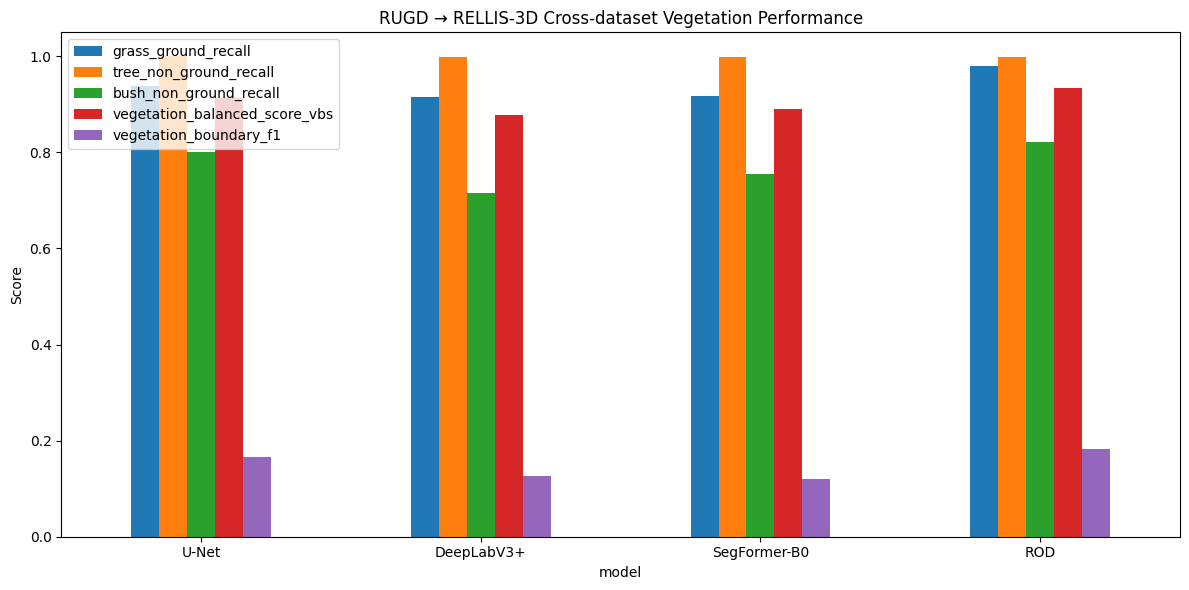

Saved: /content/drive/MyDrive/IRP/05_vegetation_evaluation/02_rellis_cross_dataset/rellis_cross_dataset_vegetation_metrics.png


In [26]:

# 26. Summary comparison plot

plot_df = (
    summary
    .set_index(
        "model"
    )
    [
        [
            "grass_ground_recall",
            "tree_non_ground_recall",
            "bush_non_ground_recall",
            "vegetation_balanced_score_vbs",
            "vegetation_boundary_f1",
        ]
    ]
)


ax = (
    plot_df.plot(
        kind="bar",
        figsize=(
            12,
            6,
        ),
    )
)


ax.set_ylabel(
    "Score"
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_title(
    "RUGD → RELLIS-3D Cross-dataset Vegetation Performance"
)



plt.xticks(
    rotation=0
)

plt.tight_layout()


PLOT_PATH = (
    OUTPUT_ROOT
    / "rellis_cross_dataset_vegetation_metrics.png"
)


plt.savefig(
    PLOT_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    PLOT_PATH
)


In [28]:

# 27. Select 5 successful scenes + 5 representative bush-failure scenes
# and generate SAME-SCENE FOUR-MODEL comparisons.
from matplotlib.patches import Patch

IGNORE_COLOUR = np.array([128, 128, 128], dtype=np.uint8)
COMPARISON_DIR = (
    OUTPUT_ROOT
    / "four_model_comparisons"
)

SUCCESS_DIR = (
    COMPARISON_DIR
    / "success_cases"
)

FAILURE_DIR = (
    COMPARISON_DIR
    / "failure_cases"
)


SUCCESS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FAILURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


MODEL_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]


NUM_SUCCESS = 5
NUM_FAILURE = 5

# Avoid visually meaningless scenes containing only a few bush pixels.
MIN_BUSH_PIXELS = 500


# ============================================================
# Helper: load saved prediction
# ============================================================

def load_model_prediction(
    model_name,
    processed_name,
):

    pred_path = (
        OUTPUT_ROOT
        / "predictions"
        / model_name.replace(
            "/",
            "_",
        )
        / processed_name
    )


    if not pred_path.exists():

        raise FileNotFoundError(
            f"Prediction not found: "
            f"{pred_path}"
        )


    return np.array(
        Image.open(
            pred_path
        ).convert("L")
    ).astype(
        np.uint8
    )


# ============================================================
# Helper: vegetation-specific error overlay
# ============================================================

def make_vegetation_error_overlay(
    rgb,
    pred,
    gt_binary,
    regions,
):

    overlay = (
        rgb.copy()
    )


    bush_error = (
        regions["bush"]
        & (
            gt_binary
            == NON_GROUND_ID
        )
        & (
            pred
            == GROUND_ID
        )
    )


    tree_error = (
        regions["tree"]
        & (
            gt_binary
            == NON_GROUND_ID
        )
        & (
            pred
            == GROUND_ID
        )
    )


    grass_error = (
        regions["grass"]
        & (
            gt_binary
            == GROUND_ID
        )
        & (
            pred
            == NON_GROUND_ID
        )
    )


    # Hide pixels excluded from evaluation before drawing errors.
    # This keeps GT, predictions and overlays visually consistent.
    # overlay[gt_binary == IGNORE_INDEX] = IGNORE_COLOUR

    # Visualization only
    overlay[
        bush_error
    ] = [
        255,
        0,
        0,
    ]

    overlay[
        tree_error
    ] = [
        255,
        165,
        0,
    ]

    overlay[
        grass_error
    ] = [
        0,
        128,
        255,
    ]


    return overlay


# ============================================================
# Build scene-level cross-model table
# ============================================================

scene_results = (
    per_image_results[
        per_image_results[
            "bush_pixels"
        ]
        >= MIN_BUSH_PIXELS
    ]
    .copy()
)


model_count = (
    scene_results
    .groupby(
        "processed_name"
    )["model"]
    .nunique()
)


common_scene_names = (
    model_count[
        model_count
        == len(
            MODEL_ORDER
        )
    ].index
)


scene_results = (
    scene_results[
        scene_results[
            "processed_name"
        ].isin(
            common_scene_names
        )
    ]
    .copy()
)


if len(
    scene_results
) == 0:

    raise RuntimeError(
        "No RELLIS scenes with sufficient bush pixels "
        "have predictions from all four models."
    )


print(
    f"Candidate RELLIS scenes with >= "
    f"{MIN_BUSH_PIXELS} bush pixels: "
    f"{scene_results['processed_name'].nunique()}"
)


scene_stats = (
    scene_results
    .groupby(
        "processed_name"
    )
    .agg(
        bush_pixels=(
            "bush_pixels",
            "max",
        ),

        mean_grass_recall=(
            "grass_ground_recall",
            "mean",
        ),

        mean_tree_recall=(
            "tree_non_ground_recall",
            "mean",
        ),

        mean_bush_recall=(
            "bush_non_ground_recall",
            "mean",
        ),

        mean_bush_leakage=(
            "bush_ground_leakage",
            "mean",
        ),

        mean_vbs=(
            "per_image_vbs",
            "mean",
        ),

        min_vbs=(
            "per_image_vbs",
            "min",
        ),

        max_vbs=(
            "per_image_vbs",
            "max",
        ),

        max_bush_leakage=(
            "bush_ground_leakage",
            "max",
        ),

        min_bush_leakage=(
            "bush_ground_leakage",
            "min",
        ),

        std_bush_leakage=(
            "bush_ground_leakage",
            "std",
        ),
    )
    .reset_index()
)


scene_stats[
    "std_bush_leakage"
] = (
    scene_stats[
        "std_bush_leakage"
    ]
    .fillna(0)
)


scene_stats[
    "bush_leakage_range"
] = (
    scene_stats[
        "max_bush_leakage"
    ]
    -
    scene_stats[
        "min_bush_leakage"
    ]
)


def minmax(
    series,
):

    series = (
        series.astype(
            float
        )
    )


    if (
        series.max()
        == series.min()
    ):

        return pd.Series(
            np.zeros(
                len(
                    series
                )
            ),
            index=(
                series.index
            ),
        )


    return (
        (
            series
            - series.min()
        )
        /
        (
            series.max()
            - series.min()
        )
    )


scene_stats[
    "bush_area_norm"
] = minmax(
    np.log1p(
        scene_stats[
            "bush_pixels"
        ]
    )
)


scene_stats[
    "mean_vbs_norm"
] = minmax(
    scene_stats[
        "mean_vbs"
    ]
)


scene_stats[
    "mean_leakage_norm"
] = minmax(
    scene_stats[
        "mean_bush_leakage"
    ]
)


scene_stats[
    "leakage_range_norm"
] = minmax(
    scene_stats[
        "bush_leakage_range"
    ]
)


# ------------------------------------------------------------
# Success:
# high average vegetation performance + low leakage + visible bush
# ------------------------------------------------------------

scene_stats[
    "success_score"
] = (
    0.60
    * scene_stats[
        "mean_vbs_norm"
    ]
    +
    0.25
    * (
        1.0
        - scene_stats[
            "mean_leakage_norm"
        ]
    )
    +
    0.15
    * scene_stats[
        "bush_area_norm"
    ]
)


# ------------------------------------------------------------
# Failure:
# high bush leakage + model differences + visible bush
# ------------------------------------------------------------

scene_stats[
    "failure_score"
] = (
    0.60
    * scene_stats[
        "mean_leakage_norm"
    ]
    +
    0.25
    * scene_stats[
        "leakage_range_norm"
    ]
    +
    0.15
    * scene_stats[
        "bush_area_norm"
    ]
)


success_cases = (
    scene_stats
    .sort_values(
        "success_score",
        ascending=False,
    )
    .head(
        NUM_SUCCESS
    )
    .copy()
)


failure_cases = (
    scene_stats[
        ~scene_stats[
            "processed_name"
        ].isin(
            success_cases[
                "processed_name"
            ]
        )
    ]
    .sort_values(
        "failure_score",
        ascending=False,
    )
    .head(
        NUM_FAILURE
    )
    .copy()
)


print(
    "\nSELECTED 5 SUCCESS CASES"
)

display(
    success_cases[
        [
            "processed_name",
            "bush_pixels",
            "mean_vbs",
            "mean_bush_recall",
            "mean_bush_leakage",
            "success_score",
        ]
    ].reset_index(
        drop=True
    )
)


print(
    "\nSELECTED 5 FAILURE CASES"
)

display(
    failure_cases[
        [
            "processed_name",
            "bush_pixels",
            "mean_vbs",
            "mean_bush_recall",
            "mean_bush_leakage",
            "bush_leakage_range",
            "failure_score",
        ]
    ].reset_index(
        drop=True
    )
)


# ============================================================
# Plot one same-scene four-model comparison
# ============================================================

def plot_four_model_scene(
    processed_name,
    case_type,
    rank,
):

    scene_rows = (
        scene_results[
            scene_results[
                "processed_name"
            ]
            == processed_name
        ]
        .copy()
    )


    if len(
        scene_rows
    ) != len(
        MODEL_ORDER
    ):

        raise RuntimeError(
            f"{processed_name}: expected 4 model rows, "
            f"found {len(scene_rows)}"
        )


    reference_row = (
        scene_rows.iloc[0]
    )


    rgb = np.array(
        Image.open(
            reference_row[
                "image_path"
            ]
        ).convert("RGB")
    )


    target_shape = (
        rgb.shape[:2]
    )


    # Recover corresponding dataframe row so that the original
    # semantic label can be loaded through the nested raw ZIP.
    matching_test = (
        test_df[
            (
                test_df[
                    "sequence_norm"
                ].astype(str)
                == str(
                    reference_row[
                        "sequence"
                    ]
                )
            )
            &
            (
                test_df[
                    "stem"
                ]
                == reference_row[
                    "stem"
                ]
            )
        ]
    )


    if len(
        matching_test
    ) != 1:

        raise RuntimeError(
            f"Could not uniquely map selected scene "
            f"{processed_name} back to test_df."
        )


    original_test_row = (
        matching_test.iloc[0]
    )


    (
        gt_binary,
        semantic_rgb,
        regions,
        _,
    ) = (
        prepare_gt_and_regions(
            original_test_row,
            target_shape,
        )
    )


    predictions = {}


    for model_name in (
        MODEL_ORDER
    ):

        pred = (
            load_model_prediction(
                model_name,
                processed_name,
            )
        )


        if pred.shape != (
            target_shape
        ):

            pred = (
                resize_nearest(
                    pred,
                    target_shape,
                )
            )


        predictions[
            model_name
        ] = pred


    # ========================================================
    # COMBINED FIGURE:
    #
    # Row 1:
    # RGB | Binary GT | U-Net | DeepLabV3+ | SegFormer-B0 | ROD
    #
    # Row 2:
    #     |           | U-Net error | DeepLab error |
    #                   SegFormer error | ROD error
    # ========================================================

    fig, axes = plt.subplots(
    2,
    6,
    figsize=(24, 10),
    gridspec_kw={
        "hspace": 0.02,
        "wspace": 0.12,
    },
)


# ========================================================
# ROW 1
# ========================================================

# --------------------------------------------------------
# RGB
# --------------------------------------------------------

    axes[0, 0].imshow(rgb)

    axes[0, 0].set_title(
        "RGB",
        fontsize=18,
        fontweight="bold",
    )

    axes[0, 0].axis("off")
    #axes[0, 0].set_anchor("S")


    # --------------------------------------------------------
    # Binary GT: black = non-ground, white = ground, grey = ignore
    # --------------------------------------------------------

    gt_display = np.full((*target_shape, 3), IGNORE_COLOUR, dtype=np.uint8)
    gt_display[gt_binary == NON_GROUND_ID] = [0, 0, 0]
    gt_display[gt_binary == GROUND_ID] = [255, 255, 255]
    gt_display[gt_binary == IGNORE_INDEX] = IGNORE_COLOUR
    axes[0, 1].imshow(gt_display)

    axes[0, 1].set_title(
        "Binary GT",
        fontsize=18,
        fontweight="bold",
    )

    axes[0, 1].axis("off")
    #axes[0, 1].set_anchor("S")


    # --------------------------------------------------------
    # Model predictions
    # --------------------------------------------------------

    for col_idx, model_name in enumerate(
        MODEL_ORDER,
        start=2,
    ):

        pred = predictions[model_name]
        pred_display = np.full((*target_shape, 3), IGNORE_COLOUR, dtype=np.uint8)
        pred_display[pred == NON_GROUND_ID] = [0, 0, 0]
        pred_display[pred == GROUND_ID] = [255, 255, 255]
        pred_display[gt_binary == IGNORE_INDEX] = IGNORE_COLOUR
        axes[0, col_idx].imshow(pred_display)

        axes[0, col_idx].set_title(
            model_name,
            fontsize=18,
            fontweight="bold",
        )

        axes[0, col_idx].axis("off")

        # Bring first row closer to second row
        #axes[0, col_idx].set_anchor("S")


    # ========================================================
    # ROW 2
    # ========================================================

    # First two positions intentionally left blank
    axes[1, 0].axis("off")
    axes[1, 1].axis("off")


    # --------------------------------------------------------
    # Vegetation error overlays
    # --------------------------------------------------------

    for col_idx, model_name in enumerate(
        MODEL_ORDER,
        start=2,
    ):

        error_overlay = (
            make_vegetation_error_overlay(
                rgb,
                predictions[model_name],
                gt_binary,
                regions,
            )
        )


        model_row = scene_rows[
            scene_rows["model"]
            == model_name
        ].iloc[0]


        axes[1, col_idx].imshow(
            error_overlay
        )


        # ----------------------------------------------------
        # Remove coordinates, axes frame and grid
        # ----------------------------------------------------

        axes[1, col_idx].set_xticks([])
        axes[1, col_idx].set_yticks([])

        axes[1, col_idx].grid(False)

        for spine in axes[1, col_idx].spines.values():
            spine.set_visible(False)


        # Bring second row closer to first row
        axes[1, col_idx].set_anchor("N")


        # ----------------------------------------------------
        # Bush recall + leakage below corresponding image
        # ----------------------------------------------------

        axes[1, col_idx].set_xlabel(
            f"Bush R={model_row['bush_non_ground_recall']:.3f}\n"
            f"Leak={model_row['bush_ground_leakage']:.3f}",
            fontsize=18,
            labelpad=4,
        )


    # ========================================================
    # Legend
    # ========================================================

    legend_elements = [
        Patch(
            facecolor="black",
            edgecolor="black",
            label="Correct non-ground",
        ),
        Patch(
            facecolor="white",
            edgecolor="black",
            label="Correct ground",
        ),
        Patch(
            facecolor=IGNORE_COLOUR / 255.0,
            edgecolor="black",
            label="Ignore",
        ),
        Patch(
            facecolor="red",
            label="Bush → Ground",
        ),
        Patch(
            facecolor="orange",
            label="Tree → Ground",
        ),
        Patch(
            facecolor="dodgerblue",
            label="Grass → Non-ground",
        ),
    ]


    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=6,
        fontsize=18,
        frameon=False,
        bbox_to_anchor=(
            0.5,
            0.15,
        ),
    )

    fig.subplots_adjust(
      left=0.015,
      right=0.995,
      top=0.90,
      bottom=0.09,
      wspace=0.12,
      hspace=0.08,
    )


    # ========================================================
    # Overall title
    # ========================================================

    case_label = (
        "Successful Vegetation Case"
        if case_type == "success"
        else "Representative Bush Failure"
    )


    fig.suptitle(
        f"{case_label} #{rank}: {processed_name}",
        fontsize=18,
        fontweight="bold",
        y=0.98,
    )


    # ========================================================
    # Layout
    # ========================================================

    fig.subplots_adjust(
        left=0.015,
        right=0.995,
        top=0.90,
        bottom=0.13,
        wspace=0.12,
        hspace=0.08,
    )
    # ========================================================
    # Save
    # ========================================================

    save_dir = (
        SUCCESS_DIR
        if case_type == "success"
        else FAILURE_DIR
    )


    combined_path = (
        save_dir
        / f"{rank:02d}_{processed_name}_combined.png"
    )


    plt.savefig(
        combined_path,
        dpi=250,
        # bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


    return {
      "case_type": case_type,
      "rank": rank,
      "processed_name": processed_name,
      "combined_figure": str(
          combined_path
      ),
    }


# ============================================================
# Generate 5 success + 5 failure cases
# ============================================================

saved_cases = []


print(
    "\nGENERATING 5 SUCCESS CASES"
)


for rank, (_, case_row) in enumerate(
    success_cases.iterrows(),
    start=1,
):

    name = (
        case_row[
            "processed_name"
        ]
    )


    print(
        f"\nSuccess "
        f"{rank}/{NUM_SUCCESS}: "
        f"{name}"
    )


    saved_cases.append(
        plot_four_model_scene(
            name,
            case_type="success",
            rank=rank,
        )
    )


print(
    "\nGENERATING 5 FAILURE CASES"
)


for rank, (_, case_row) in enumerate(
    failure_cases.iterrows(),
    start=1,
):

    name = (
        case_row[
            "processed_name"
        ]
    )


    print(
        f"\nFailure "
        f"{rank}/{NUM_FAILURE}: "
        f"{name}"
    )


    saved_cases.append(
        plot_four_model_scene(
            name,
            case_type="failure",
            rank=rank,
        )
    )


# ============================================================
# Save rankings and paths
# ============================================================

success_cases.to_csv(
    COMPARISON_DIR
    / "selected_5_success_cases.csv",
    index=False,
)


failure_cases.to_csv(
    COMPARISON_DIR
    / "selected_5_failure_cases.csv",
    index=False,
)


scene_stats.sort_values(
    "failure_score",
    ascending=False,
).to_csv(
    COMPARISON_DIR
    / "all_scene_rankings.csv",
    index=False,
)


pd.DataFrame(
    saved_cases
).to_csv(
    COMPARISON_DIR
    / "selected_case_figure_paths.csv",
    index=False,
)


print(
    "\nQualitative outputs saved under:"
)

print(
    COMPARISON_DIR
)


Output hidden; open in https://colab.research.google.com to view.


## Main outputs

Saved to:

`/content/drive/MyDrive/IRP/05_vegetation_evaluation/02_rellis_cross_dataset/`

Key files:

- `rellis_cross_dataset_vegetation_summary.csv`
- `rellis_cross_dataset_vegetation_per_image.csv`
- `rellis_cross_dataset_vegetation_table.tex`
- `rellis_cross_dataset_vegetation_metrics.png`
- `evaluation_config.json`
- `predictions/`
- `four_model_comparisons/success_cases/`
- `four_model_comparisons/failure_cases/`
- `four_model_comparisons/selected_5_success_cases.csv`
- `four_model_comparisons/selected_5_failure_cases.csv`

For the dissertation quantitative table, use the **dataset-level globally aggregated metrics** in `rellis_cross_dataset_vegetation_summary.csv`.
